In [7]:
import pandas as pd
from pathlib import Path
import numpy as np
import anndata
import time
import matplotlib.pyplot as plt

from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

In [8]:
download_base = Path('../data/abc_atlas')
abc_cache = AbcProjectCache.from_cache_dir(download_base)

abc_cache.current_manifest

'releases/20250531/manifest.json'

In [9]:
abc_cache.list_metadata_files('WMB-10X')

['cell_metadata',
 'cell_metadata_with_cluster_annotation',
 'example_genes_all_cells_expression',
 'gene',
 'region_of_interest_metadata']

In [10]:
abc_cache.list_metadata_files('WMB-taxonomy')


['cluster',
 'cluster_annotation_term',
 'cluster_annotation_term_set',
 'cluster_annotation_term_with_counts',
 'cluster_to_cluster_annotation_membership',
 'cluster_to_cluster_annotation_membership_color',
 'cluster_to_cluster_annotation_membership_pivoted']

In [11]:
abc_cache.get_directory_metadata('WMB-taxonomy')


cluster_annotation_term_with_counts.csv: 100%|█| 902k/902k [00:01<00:00, 769kMB/
cluster_to_cluster_annotation_membership.csv: 100%|█| 2.21M/2.21M [00:01<00:00, 
cluster_to_cluster_annotation_membership_color.csv: 100%|█| 239k/239k [00:00<00:
cluster_to_cluster_annotation_membership_pivoted.csv: 100%|█| 531k/531k [00:00<0


[PosixPath('/Users/chrislangseth/work/karolinska_institutet/projects/oligo-mtDSB/data/abc_atlas/metadata/WMB-taxonomy/20231215/cluster.csv'),
 PosixPath('/Users/chrislangseth/work/karolinska_institutet/projects/oligo-mtDSB/data/abc_atlas/metadata/WMB-taxonomy/20231215/cluster_annotation_term.csv'),
 PosixPath('/Users/chrislangseth/work/karolinska_institutet/projects/oligo-mtDSB/data/abc_atlas/metadata/WMB-taxonomy/20231215/cluster_annotation_term_set.csv'),
 PosixPath('/Users/chrislangseth/work/karolinska_institutet/projects/oligo-mtDSB/data/abc_atlas/metadata/WMB-taxonomy/20231215/views/cluster_annotation_term_with_counts.csv'),
 PosixPath('/Users/chrislangseth/work/karolinska_institutet/projects/oligo-mtDSB/data/abc_atlas/metadata/WMB-taxonomy/20231215/cluster_to_cluster_annotation_membership.csv'),
 PosixPath('/Users/chrislangseth/work/karolinska_institutet/projects/oligo-mtDSB/data/abc_atlas/metadata/WMB-taxonomy/20231215/views/cluster_to_cluster_annotation_membership_color.csv'),


In [12]:
abc_cache.list_data_files('WMB-10Xv3')


['WMB-10Xv3-CB/log2',
 'WMB-10Xv3-CB/raw',
 'WMB-10Xv3-CTXsp/log2',
 'WMB-10Xv3-CTXsp/raw',
 'WMB-10Xv3-HPF/log2',
 'WMB-10Xv3-HPF/raw',
 'WMB-10Xv3-HY/log2',
 'WMB-10Xv3-HY/raw',
 'WMB-10Xv3-Isocortex-1/log2',
 'WMB-10Xv3-Isocortex-1/raw',
 'WMB-10Xv3-Isocortex-2/log2',
 'WMB-10Xv3-Isocortex-2/raw',
 'WMB-10Xv3-MB/log2',
 'WMB-10Xv3-MB/raw',
 'WMB-10Xv3-MY/log2',
 'WMB-10Xv3-MY/raw',
 'WMB-10Xv3-OLF/log2',
 'WMB-10Xv3-OLF/raw',
 'WMB-10Xv3-P/log2',
 'WMB-10Xv3-P/raw',
 'WMB-10Xv3-PAL/log2',
 'WMB-10Xv3-PAL/raw',
 'WMB-10Xv3-STR/log2',
 'WMB-10Xv3-STR/raw',
 'WMB-10Xv3-TH/log2',
 'WMB-10Xv3-TH/raw']

In [13]:
cell = abc_cache.get_metadata_dataframe(
    directory='WMB-10X',
    file_name='cell_metadata',
    dtype={'cell_label': str}
)
cell.set_index('cell_label', inplace=True)
print("Number of cells = ", len(cell))
cell.head(5)


cell_metadata.csv: 100%|██████████████████| 1.01G/1.01G [15:38<00:00, 1.07MMB/s]


Number of cells =  4042976


,cell_barcode,barcoded_cell_sample_label,library_label,feature_matrix_label,entity,brain_section_label,library_method,region_of_interest_acronym,donor_label,donor_genotype,donor_sex,dataset_label,x,y,cluster_alias,abc_sample_id
cell_label,,,,,,,,,,,,,,,,
GCGAGAAGTTAAGGGC-410_B05,GCGAGAAGTTAAGGGC,410_B05,L8TX_201030_01_C12,WMB-10Xv3-HPF,cell,NaN,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550850,Ai14(RCL-tdT)/wt,F,WMB-10Xv3,23.146826,-3.086639,1,484be5df-5d44-4bfe-9652-7b5bc739c211
AATGGCTCAGCTCCTT-411_B06,AATGGCTCAGCTCCTT,411_B06,L8TX_201029_01_E10,WMB-10Xv3-HPF,cell,NaN,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550851,Ai14(RCL-tdT)/wt,F,WMB-10Xv3,23.138481,-3.022000,1,5638505d-e1e8-457f-9e5b-59e3e2302417
AACACACGTTGCTTGA-410_B05,AACACACGTTGCTTGA,410_B05,L8TX_201030_01_C12,WMB-10Xv3-HPF,cell,NaN,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550850,Ai14(RCL-tdT)/wt,F,WMB-10Xv3,23.472557,-2.992709,1,a0544e29-194f-4d34-9af4-13e7377b648f
CACAGATAGAGGCGGA-410_A05,CACAGATAGAGGCGGA,410_A05,L8TX_201029_01_A10,WMB-10Xv3-HPF,cell,NaN,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550850,Ai14(RCL-tdT)/wt,F,WMB-10Xv3,23.379622,-3.043442,1,c777ac0b-77e1-4d76-bf8e-2b3d9e08b253
AAAGTGAAGCATTTCG-410_B05,AAAGTGAAGCATTTCG,410_B05,L8TX_201030_01_C12,WMB-10Xv3-HPF,cell,NaN,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550850,Ai14(RCL-tdT)/wt,F,WMB-10Xv3,23.909480,-2.601536,1,49860925-e82b-46df-a228-fd2f97e75d39


In [14]:
def print_column_info(df):
    
    for c in df.columns:
        grouped = df[[c]].groupby(c).count()
        members = ''
        if len(grouped) < 30:
            members = str(list(grouped.index))
        print("Number of unique %s = %d %s" % (c, len(grouped), members))
        


In [15]:
cell.groupby('dataset_label')[['x']].count()


,x
dataset_label,
WMB-10XMulti,1687
WMB-10Xv2,1699939
WMB-10Xv3,2341350


In [16]:
cluster_colors = abc_cache.get_metadata_dataframe(
    directory='WMB-taxonomy',
    file_name='cluster_to_cluster_annotation_membership_color'
)
cluster_colors.set_index('cluster_alias', inplace=True)
cluster_colors.head(5)

,neurotransmitter_color,class_color,subclass_color,supertype_color,cluster_color
cluster_alias,,,,,
1,#2B93DF,#FA0087,#0F6632,#266DFF,#64661F
2,#2B93DF,#FA0087,#0F6632,#266DFF,#CCA73D
3,#2B93DF,#FA0087,#0F6632,#002BCC,#99000D
4,#2B93DF,#FA0087,#0F6632,#002BCC,#5C8899
5,#2B93DF,#FA0087,#0F6632,#002BCC,#473D66


In [17]:
roi = abc_cache.get_metadata_dataframe(directory='WMB-10X', file_name='region_of_interest_metadata')
roi.set_index('acronym', inplace=True)
roi.rename(columns={'order': 'region_of_interest_order',
                    'color_hex_triplet': 'region_of_interest_color'},
           inplace=True)
roi.head(5)

region_of_interest_metadata.csv: 100%|████| 1.40k/1.40k [00:00<00:00, 5.07kMB/s]


,label,name,region_of_interest_order,region_of_interest_color
acronym,,,,
MO-FRP,WMB-MO-FRP,Somatomotor - Frontal pole,0,#3DCC7C
MOp,WMB-MOp,Primary motor area,1,#179968
SS-GU-VISC,WMB-SS-GU-VISC,Somatosensory/gustatory/visceral areas,2,#2E8599
SSp,WMB-SSp,Primary somatosensory area,3,#5CCCCC
AUD,WMB-AUD,Auditory areas,4,#455A99


In [19]:
cluster_details = abc_cache.get_metadata_dataframe(
    directory='WMB-taxonomy',
    file_name='cluster_to_cluster_annotation_membership_pivoted',
    keep_default_na=False
)
cluster_details.set_index('cluster_alias', inplace=True)
cluster_details.head(5)

,neurotransmitter,class,subclass,supertype,cluster
cluster_alias,,,,,
1,Glut,01 IT-ET Glut,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0326 L2 IT PPP-APr Glut_3
2,Glut,01 IT-ET Glut,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0327 L2 IT PPP-APr Glut_3
3,Glut,01 IT-ET Glut,018 L2 IT PPP-APr Glut,0081 L2 IT PPP-APr Glut_2,0322 L2 IT PPP-APr Glut_2
4,Glut,01 IT-ET Glut,018 L2 IT PPP-APr Glut,0081 L2 IT PPP-APr Glut_2,0323 L2 IT PPP-APr Glut_2
5,Glut,01 IT-ET Glut,018 L2 IT PPP-APr Glut,0081 L2 IT PPP-APr Glut_2,0325 L2 IT PPP-APr Glut_2


In [20]:
cell_extended = cell.join(cluster_details, on='cluster_alias')
cell_extended = cell_extended.join(cluster_colors, on='cluster_alias')
cell_extended = cell_extended.join(roi[['region_of_interest_order', 'region_of_interest_color']], on='region_of_interest_acronym')
cell_extended.head(5)

,cell_barcode,barcoded_cell_sample_label,library_label,feature_matrix_label,entity,brain_section_label,library_method,region_of_interest_acronym,donor_label,donor_genotype,...,subclass,supertype,cluster,neurotransmitter_color,class_color,subclass_color,supertype_color,cluster_color,region_of_interest_order,region_of_interest_color
cell_label,,,,,,,,,,,,,,,,,,,,,
GCGAGAAGTTAAGGGC-410_B05,GCGAGAAGTTAAGGGC,410_B05,L8TX_201030_01_C12,WMB-10Xv3-HPF,cell,NaN,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550850,Ai14(RCL-tdT)/wt,...,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0326 L2 IT PPP-APr Glut_3,#2B93DF,#FA0087,#0F6632,#266DFF,#64661F,15,#CCB05C
AATGGCTCAGCTCCTT-411_B06,AATGGCTCAGCTCCTT,411_B06,L8TX_201029_01_E10,WMB-10Xv3-HPF,cell,NaN,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550851,Ai14(RCL-tdT)/wt,...,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0326 L2 IT PPP-APr Glut_3,#2B93DF,#FA0087,#0F6632,#266DFF,#64661F,15,#CCB05C
AACACACGTTGCTTGA-410_B05,AACACACGTTGCTTGA,410_B05,L8TX_201030_01_C12,WMB-10Xv3-HPF,cell,NaN,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550850,Ai14(RCL-tdT)/wt,...,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0326 L2 IT PPP-APr Glut_3,#2B93DF,#FA0087,#0F6632,#266DFF,#64661F,15,#CCB05C
CACAGATAGAGGCGGA-410_A05,CACAGATAGAGGCGGA,410_A05,L8TX_201029_01_A10,WMB-10Xv3-HPF,cell,NaN,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550850,Ai14(RCL-tdT)/wt,...,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0326 L2 IT PPP-APr Glut_3,#2B93DF,#FA0087,#0F6632,#266DFF,#64661F,15,#CCB05C
AAAGTGAAGCATTTCG-410_B05,AAAGTGAAGCATTTCG,410_B05,L8TX_201030_01_C12,WMB-10Xv3-HPF,cell,NaN,10Xv3,RHP,Snap25-IRES2-Cre;Ai14-550850,Ai14(RCL-tdT)/wt,...,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0326 L2 IT PPP-APr Glut_3,#2B93DF,#FA0087,#0F6632,#266DFF,#64661F,15,#CCB05C


In [21]:
cluster_colors = abc_cache.get_metadata_dataframe(
    directory='WMB-taxonomy',
    file_name='cluster_to_cluster_annotation_membership_color'
)
cluster_colors.set_index('cluster_alias', inplace=True)
cluster_colors.head(5)

,neurotransmitter_color,class_color,subclass_color,supertype_color,cluster_color
cluster_alias,,,,,
1,#2B93DF,#FA0087,#0F6632,#266DFF,#64661F
2,#2B93DF,#FA0087,#0F6632,#266DFF,#CCA73D
3,#2B93DF,#FA0087,#0F6632,#002BCC,#99000D
4,#2B93DF,#FA0087,#0F6632,#002BCC,#5C8899
5,#2B93DF,#FA0087,#0F6632,#002BCC,#473D66


In [22]:
print_column_info(cell_extended)


Number of unique cell_barcode = 2375490 
Number of unique barcoded_cell_sample_label = 819 
Number of unique library_label = 819 
Number of unique feature_matrix_label = 24 ['WMB-10XMulti', 'WMB-10Xv2-CTXsp', 'WMB-10Xv2-HPF', 'WMB-10Xv2-HY', 'WMB-10Xv2-Isocortex-1', 'WMB-10Xv2-Isocortex-2', 'WMB-10Xv2-Isocortex-3', 'WMB-10Xv2-Isocortex-4', 'WMB-10Xv2-MB', 'WMB-10Xv2-OLF', 'WMB-10Xv2-TH', 'WMB-10Xv3-CB', 'WMB-10Xv3-CTXsp', 'WMB-10Xv3-HPF', 'WMB-10Xv3-HY', 'WMB-10Xv3-Isocortex-1', 'WMB-10Xv3-Isocortex-2', 'WMB-10Xv3-MB', 'WMB-10Xv3-MY', 'WMB-10Xv3-OLF', 'WMB-10Xv3-P', 'WMB-10Xv3-PAL', 'WMB-10Xv3-STR', 'WMB-10Xv3-TH']
Number of unique entity = 1 ['cell']
Number of unique brain_section_label = 0 []
Number of unique library_method = 3 ['10Xv2', '10Xv3', '10xRSeq_Mult']
Number of unique region_of_interest_acronym = 29 ['ACA', 'AI', 'AUD', 'AUD-TEa-PERI-ECT', 'CB', 'CTXsp', 'ENT', 'HIP', 'HY', 'LSX', 'MB', 'MO-FRP', 'MOp', 'MY', 'OLF', 'P', 'PAL', 'PL-ILA-ORB', 'RHP', 'RSP', 'SS-GU-VISC', 'SS

In [23]:
def plot_umap(xx, yy, cc=None, val=None, fig_width=8, fig_height=8, cmap=None):

    fig, ax = plt.subplots()
    fig.set_size_inches(fig_width, fig_height)
    
    if cmap is not None :
        plt.scatter(xx, yy, s=0.5, c=val, marker='.', cmap=cmap)
    elif cc is not None :
        plt.scatter(xx, yy, s=0.5, color=cc, marker='.')
        
    ax.axis('equal')
    ax.set_xlim(-18, 27)
    ax.set_ylim(-18, 27)
    ax.set_xticks([])
    ax.set_yticks([])
    
    return fig, ax

In [24]:
cell_subsampled = cell_extended.loc[::10]
print(len(cell_subsampled))

404298


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


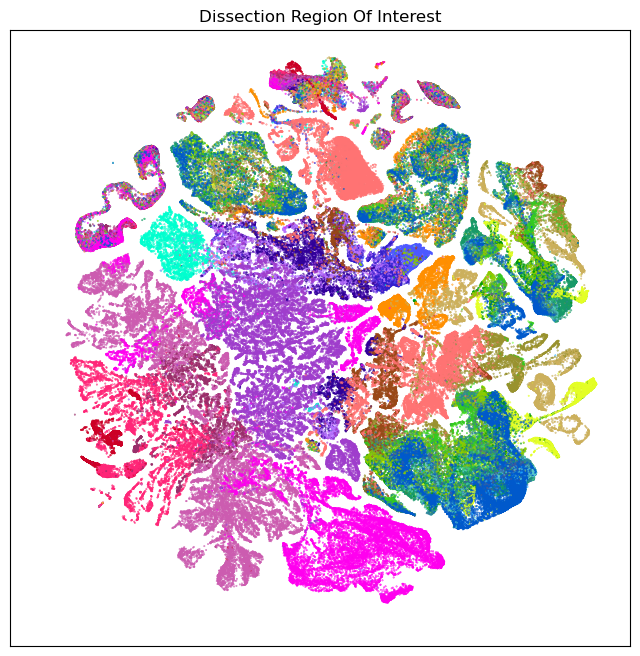

In [25]:
fig, ax = plot_umap(cell_subsampled['x'], cell_subsampled['y'], cc=cell_subsampled['region_of_interest_color'])
res = ax.set_title("Dissection Region Of Interest")
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


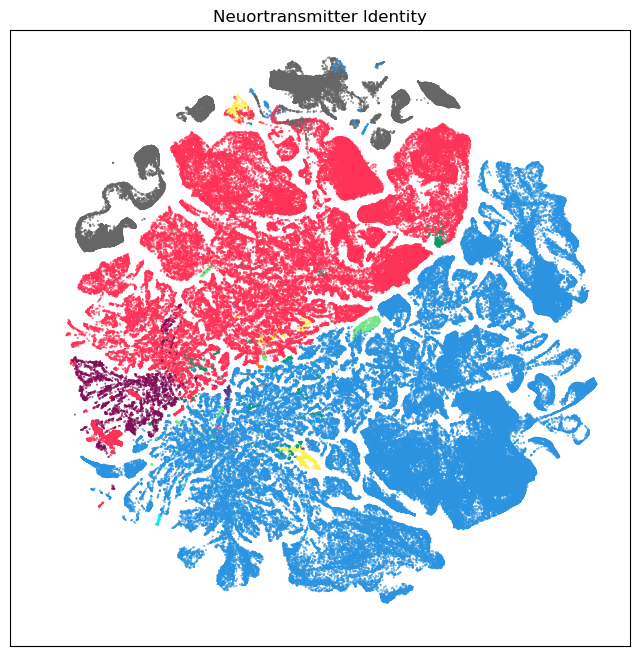

In [26]:
fig, ax = plot_umap(cell_subsampled['x'], cell_subsampled['y'], cc=cell_subsampled['neurotransmitter_color'])
res = ax.set_title("Neuortransmitter Identity")
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


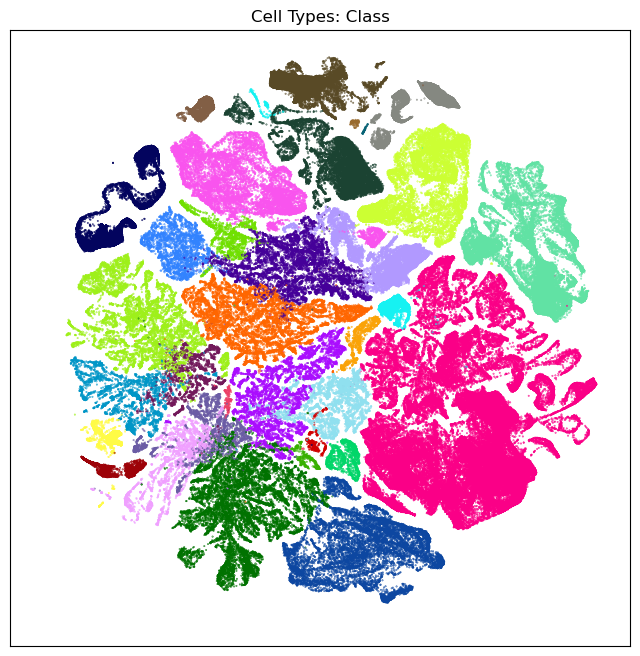

In [27]:
fig, ax = plot_umap(cell_subsampled['x'], cell_subsampled['y'], cc=cell_subsampled['class_color'])
res = ax.set_title("Cell Types: Class")
plt.show()


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


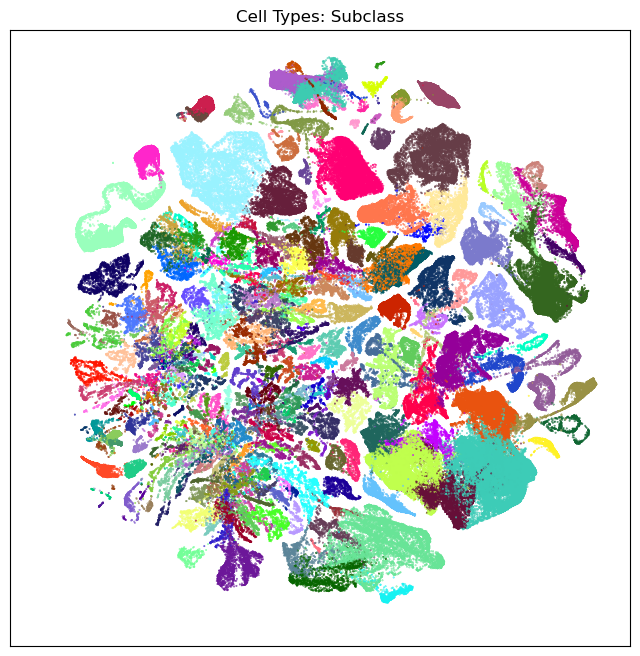

In [28]:
fig, ax = plot_umap(cell_subsampled['x'], cell_subsampled['y'], cc=cell_subsampled['subclass_color'])
res = ax.set_title("Cell Types: Subclass")
plt.show()


In [29]:
gene = abc_cache.get_metadata_dataframe(directory='WMB-10X', file_name='gene')
gene.set_index('gene_identifier', inplace=True)
print("Number of genes = ", len(gene))
gene.head(5)

gene.csv: 100%|███████████████████████████| 2.30M/2.30M [00:01<00:00, 1.39MMB/s]

Number of genes =  32285


,gene_symbol,name,mapped_ncbi_identifier,comment
gene_identifier,,,,
ENSMUSG00000051951,Xkr4,X-linked Kx blood group related 4,NCBIGene:497097,NaN
ENSMUSG00000089699,Gm1992,predicted gene 1992,NaN,NaN
ENSMUSG00000102331,Gm19938,"predicted gene, 19938",NaN,NaN
ENSMUSG00000102343,Gm37381,"predicted gene, 37381",NaN,NaN
ENSMUSG00000025900,Rp1,retinitis pigmentosa 1 (human),NCBIGene:19888,NaN


In [30]:
pred = (gene['comment'] == 'no expression')
filtered = gene[pred]
print("Number of no expression genes", len(filtered))
filtered

Number of no expression genes 1173


,gene_symbol,name,mapped_ncbi_identifier,comment
gene_identifier,,,,
ENSMUSG00000118272,Arhgef4,Rho guanine nucleotide exchange factor (GEF) 4,NaN,no expression
ENSMUSG00000117809,Asdurf,Asnsd1 upstream reading frame,NCBIGene:110599589,no expression
ENSMUSG00000047383,AC169382.1,novel transcript,NaN,no expression
ENSMUSG00000097001,1700054K02Rik,RIKEN cDNA 1700054K02 gene,NaN,no expression
ENSMUSG00000116048,Sept2,septin 2,NaN,no expression
...,...,...,...,...
ENSMUSG00000091585,AC140365.1,PRAME family member 8-like,NaN,no expression
ENSMUSG00000095523,AC124606.1,PRAME family member 8-like,NCBIGene:100038995,no expression
ENSMUSG00000095475,AC133095.2,uncharacterized LOC545763,NCBIGene:545763,no expression


In [31]:
abc_cache.list_data_files('WMB-10Xv2')


['WMB-10Xv2-CTXsp/log2',
 'WMB-10Xv2-CTXsp/raw',
 'WMB-10Xv2-HPF/log2',
 'WMB-10Xv2-HPF/raw',
 'WMB-10Xv2-HY/log2',
 'WMB-10Xv2-HY/raw',
 'WMB-10Xv2-Isocortex-1/log2',
 'WMB-10Xv2-Isocortex-1/raw',
 'WMB-10Xv2-Isocortex-2/log2',
 'WMB-10Xv2-Isocortex-2/raw',
 'WMB-10Xv2-Isocortex-3/log2',
 'WMB-10Xv2-Isocortex-3/raw',
 'WMB-10Xv2-Isocortex-4/log2',
 'WMB-10Xv2-Isocortex-4/raw',
 'WMB-10Xv2-MB/log2',
 'WMB-10Xv2-MB/raw',
 'WMB-10Xv2-OLF/log2',
 'WMB-10Xv2-OLF/raw',
 'WMB-10Xv2-TH/log2',
 'WMB-10Xv2-TH/raw']

In [34]:
feature_matrix_label = 'WMB-10Xv2-TH'
file = abc_cache.get_data_path(directory='WMB-10Xv2', file_name='WMB-10Xv2-TH/log2')
print(file)

WMB-10Xv2-TH-log2.h5ad: 100%|█████████████| 4.04G/4.04G [35:39<00:00, 1.89MMB/s]

/Users/chrislangseth/work/karolinska_institutet/projects/oligo-mtDSB/data/abc_atlas/expression_matrices/WMB-10Xv2/20230630/WMB-10Xv2-TH-log2.h5ad


In [35]:
adata = anndata.read_h5ad(file, backed='r')
print(adata)

AnnData object with n_obs × n_vars = 131212 × 32285 backed at '/Users/chrislangseth/work/karolinska_institutet/projects/oligo-mtDSB/data/abc_atlas/expression_matrices/WMB-10Xv2/20230630/WMB-10Xv2-TH-log2.h5ad'
    obs: 'cell_barcode', 'library_label', 'anatomical_division_label'
    var: 'gene_symbol'
    uns: 'normalization', 'parent', 'parent_layer', 'parent_rows'


In [38]:
adata.obs

,cell_barcode,library_label,anatomical_division_label
cell_label,,,
CAGGTGCAGGCTAGCA-040_C01,CAGGTGCAGGCTAGCA,L8TX_180815_01_E08,TH
TGCGCAGGTTGCGCAC-045_C01,TGCGCAGGTTGCGCAC,L8TX_180829_01_C10,TH
CGATGTATCTTGCCGT-042_B01,CGATGTATCTTGCCGT,L8TX_180829_01_B09,TH
GACTAACGTCCTCTTG-040_B01,GACTAACGTCCTCTTG,L8TX_180815_01_D08,TH
GATCGTACAACTGCTA-040_B01,GATCGTACAACTGCTA,L8TX_180815_01_D08,TH
...,...,...,...
GTACTCCGTAGTACCT-103_B01,GTACTCCGTAGTACCT,L8TX_190321_01_G03,TH
GTGAAGGTCAGCTCTC-103_B01,GTGAAGGTCAGCTCTC,L8TX_190321_01_G03,TH
ACACCCTCATGCGCAC-103_C01,ACACCCTCATGCGCAC,L8TX_190321_01_H03,TH


In [36]:
ntgenes = ['Slc17a7', 'Slc17a6', 'Slc17a8', 'Slc32a1', 'Slc6a5', 'Slc18a3', 'Slc6a3', 'Slc6a4', 'Slc6a2']
exgenes = ['Tac2']
gnames = ntgenes + exgenes
pred = [x in gnames for x in adata.var.gene_symbol]
gene_filtered = adata.var[pred]
gene_filtered

,gene_symbol
gene_identifier,
ENSMUSG00000037771,Slc32a1
ENSMUSG00000070570,Slc17a7
ENSMUSG00000039728,Slc6a5
ENSMUSG00000030500,Slc17a6
ENSMUSG00000055368,Slc6a2
ENSMUSG00000019935,Slc17a8
ENSMUSG00000025400,Tac2
ENSMUSG00000020838,Slc6a4
ENSMUSG00000021609,Slc6a3
